In [2]:
# Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotly is optional
try:
    import plotly.express as px
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
os.makedirs("figures", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150)
    plt.show()

In [3]:
# STEP 1 - Load and inspect the dataset
df = pd.read_csv("eda_retail_customers.csv", parse_dates=["purchase_date"])

print("----- head -----");  print(df.head(), "\n")
print("----- info -----");  df.info()
print("\nShape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:\n", df.isna().sum()[df.isna().sum() > 0])

# The file has a few gaps (income 2%, visits 1%, satisfaction 3%).
# Rows are KEPT; pandas skips NaN in statistics/plots, so no imputation is needed
# for EDA. (Impute only if you move on to modelling.)

num_cols = ["age", "annual_income", "quantity", "discount_pct", "purchase_amount",
            "visits_per_month", "days_since_last_purchase", "satisfaction_score"]
cat_cols = ["gender", "city", "membership", "product_category", "payment_method", "returned"]

----- head -----
  customer_id  age  gender       city  annual_income membership product_category  quantity  discount_pct  purchase_amount    payment_method purchase_date  visits_per_month  days_since_last_purchase  \
0       C0001   39  Female  Bengaluru       934000.0      Basic           Sports         3            25         20893.40               UPI    2025-11-07               5.0                         6   
1       C0002   26    Male      Delhi      1060000.0     Silver         Clothing         5            15         18538.95               UPI    2025-05-08               6.0                        16   
2       C0003   44    Male       Pune            NaN      Basic         Clothing         2            10          5805.73               UPI    2025-01-13               5.0                        27   
3       C0004   45    Male     Nashik      1068000.0      Basic   Home & Kitchen         1            10          3708.93               UPI    2025-09-24               1.0        

In [4]:
# STEP 2 - Descriptive statistics (mean, median, std, quartiles)
stats_tbl = df[num_cols].agg(["count", "mean", "median", "std", "min", "max"]).T
stats_tbl["Q1 (25%)"] = df[num_cols].quantile(0.25)
stats_tbl["Q3 (75%)"] = df[num_cols].quantile(0.75)
stats_tbl["IQR"] = stats_tbl["Q3 (75%)"] - stats_tbl["Q1 (25%)"]
stats_tbl["skew"] = df[num_cols].skew()
print(stats_tbl.round(2))

print("\nCategorical columns:")
print(df[cat_cols].describe().T)


                           count       mean     median        std        min         max   Q1 (25%)    Q3 (75%)        IQR  skew
age                       1000.0      35.85      36.00       9.53      18.00       65.00      29.00       42.00      13.00  0.15
annual_income              980.0  924552.04  915500.00  245569.74  238000.00  1709000.00  754500.00  1081250.00  326750.00  0.22
quantity                  1000.0       3.00       3.00       1.41       1.00        9.00       2.00        4.00       2.00  0.60
discount_pct              1000.0      11.06      10.00       9.06       0.00       35.00       5.00       15.00      10.00  0.58
purchase_amount           1000.0   20693.51   11408.23   29069.64     792.91   531421.68    5863.57    24903.46   19039.88  7.13
visits_per_month           990.0       3.97       4.00       2.08       0.00       12.00       2.00        5.00       3.00  0.63
days_since_last_purchase  1000.0      22.96      16.00      23.08       1.00      188.00       6.

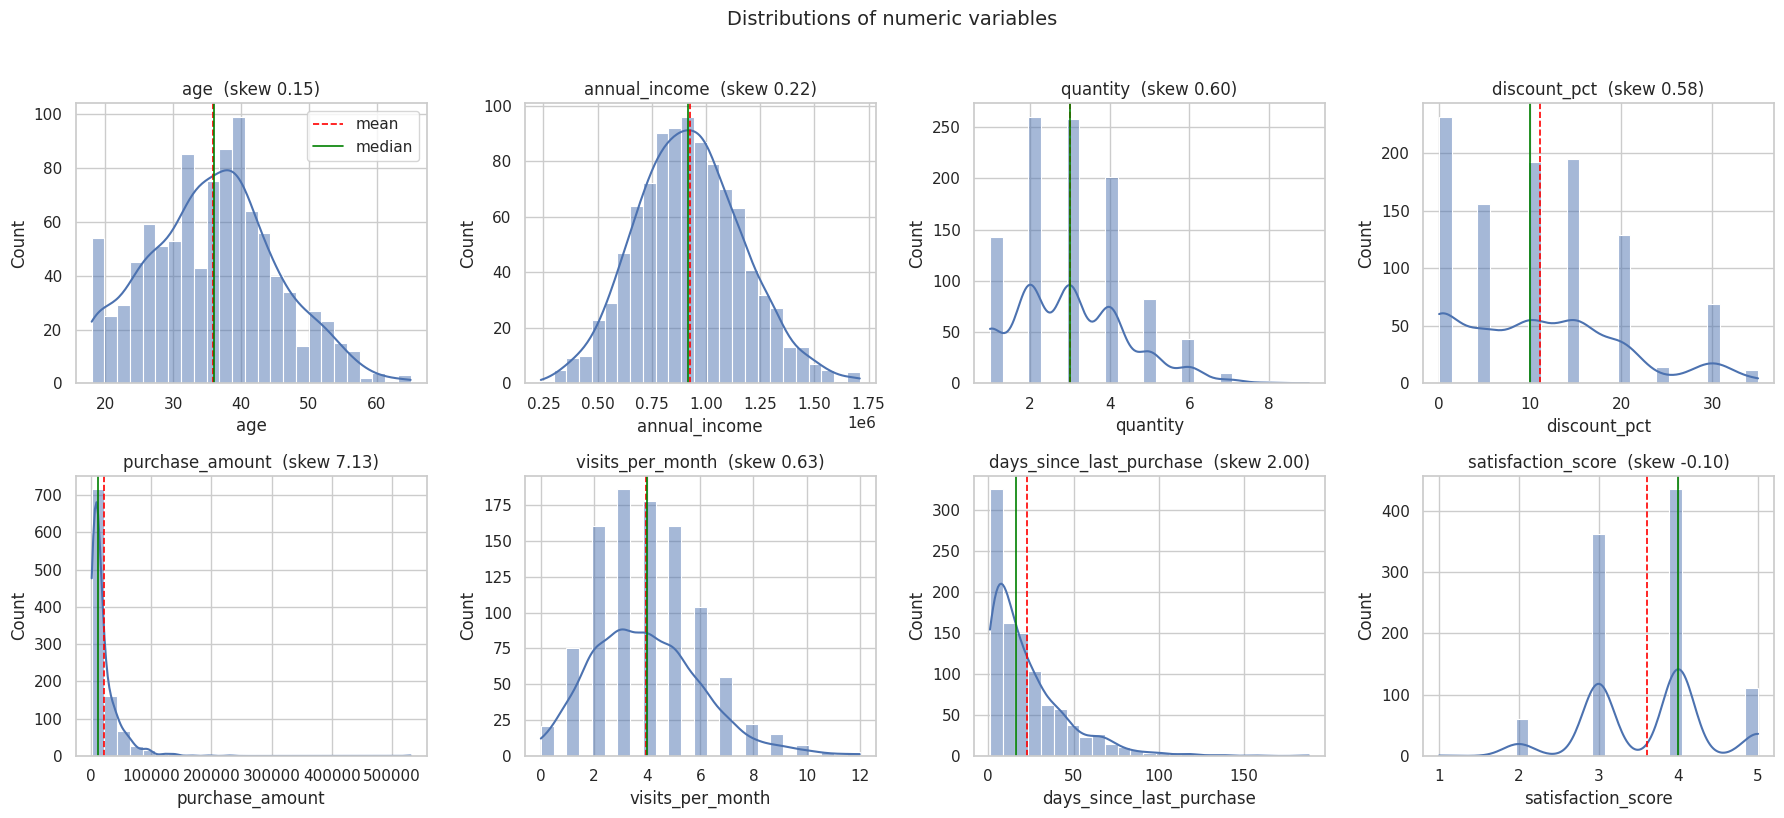

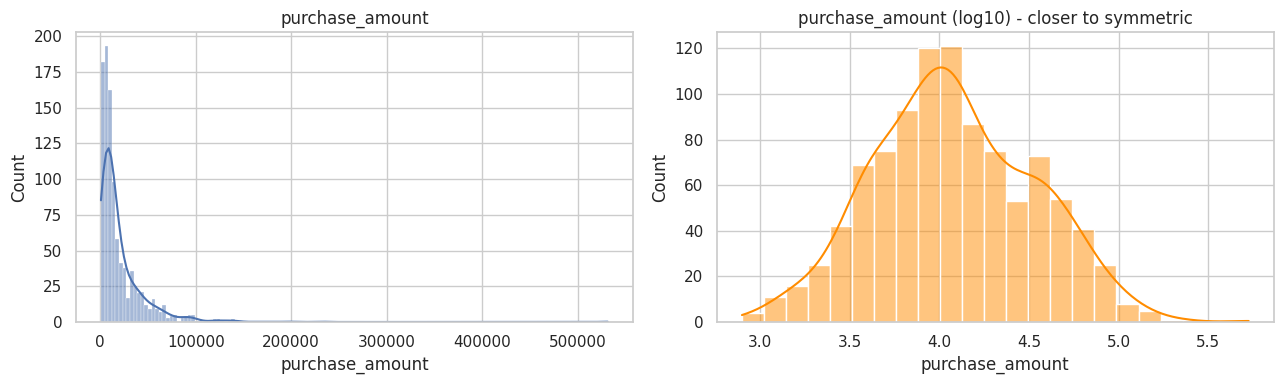

In [5]:
# STEP 3 - Histograms + KDE for numeric columns
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, bins=25, ax=ax)
    ax.axvline(df[col].mean(), color="red", ls="--", lw=1.2, label="mean")
    ax.axvline(df[col].median(), color="green", lw=1.2, label="median")
    ax.set_title(f"{col}  (skew {df[col].skew():.2f})")
axes[0, 0].legend()
plt.suptitle("Distributions of numeric variables", y=1.02, fontsize=14)
save("01_histograms_kde")

# purchase_amount is heavily right-skewed -> look at it on a log scale as well
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["purchase_amount"], kde=True, ax=axes[0]); axes[0].set_title("purchase_amount")
sns.histplot(np.log10(df["purchase_amount"]), kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("purchase_amount (log10) - closer to symmetric")
save("02_purchase_amount_log")

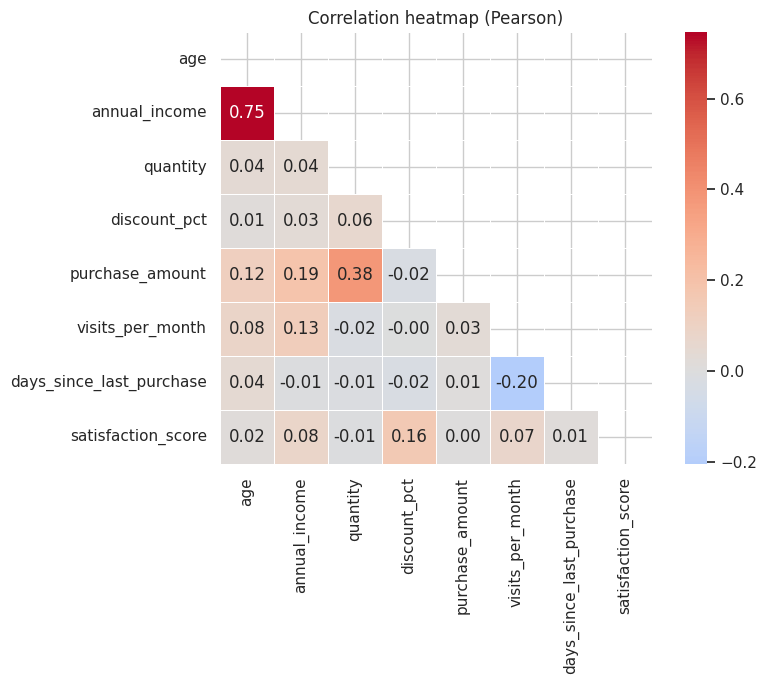


Strongest correlations:
                    var_1            var_2      r
           annual_income              age  0.746
         purchase_amount         quantity  0.384
days_since_last_purchase visits_per_month -0.204
         purchase_amount    annual_income  0.193
      satisfaction_score     discount_pct  0.161
        visits_per_month    annual_income  0.132

Spearman correlation of purchase_amount with:
quantity                    0.527
annual_income               0.232
age                         0.184
visits_per_month            0.058
satisfaction_score          0.009
discount_pct               -0.012
days_since_last_purchase   -0.023
Name: purchase_amount, dtype: float64


In [6]:
# STEP 4 - Correlation heatmap
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5)
plt.title("Correlation heatmap (Pearson)")
save("03_correlation_heatmap")

pairs = (corr.where(~mask).stack().rename("r").reset_index()
         .rename(columns={"level_0": "var_1", "level_1": "var_2"}))
pairs = pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index)
print("\nStrongest correlations:\n", pairs.head(6).round(3).to_string(index=False))

# Spearman is more reliable here because purchase_amount is so skewed
print("\nSpearman correlation of purchase_amount with:")
print(df[num_cols].corr(method="spearman")["purchase_amount"].drop("purchase_amount")
      .sort_values(ascending=False).round(3))

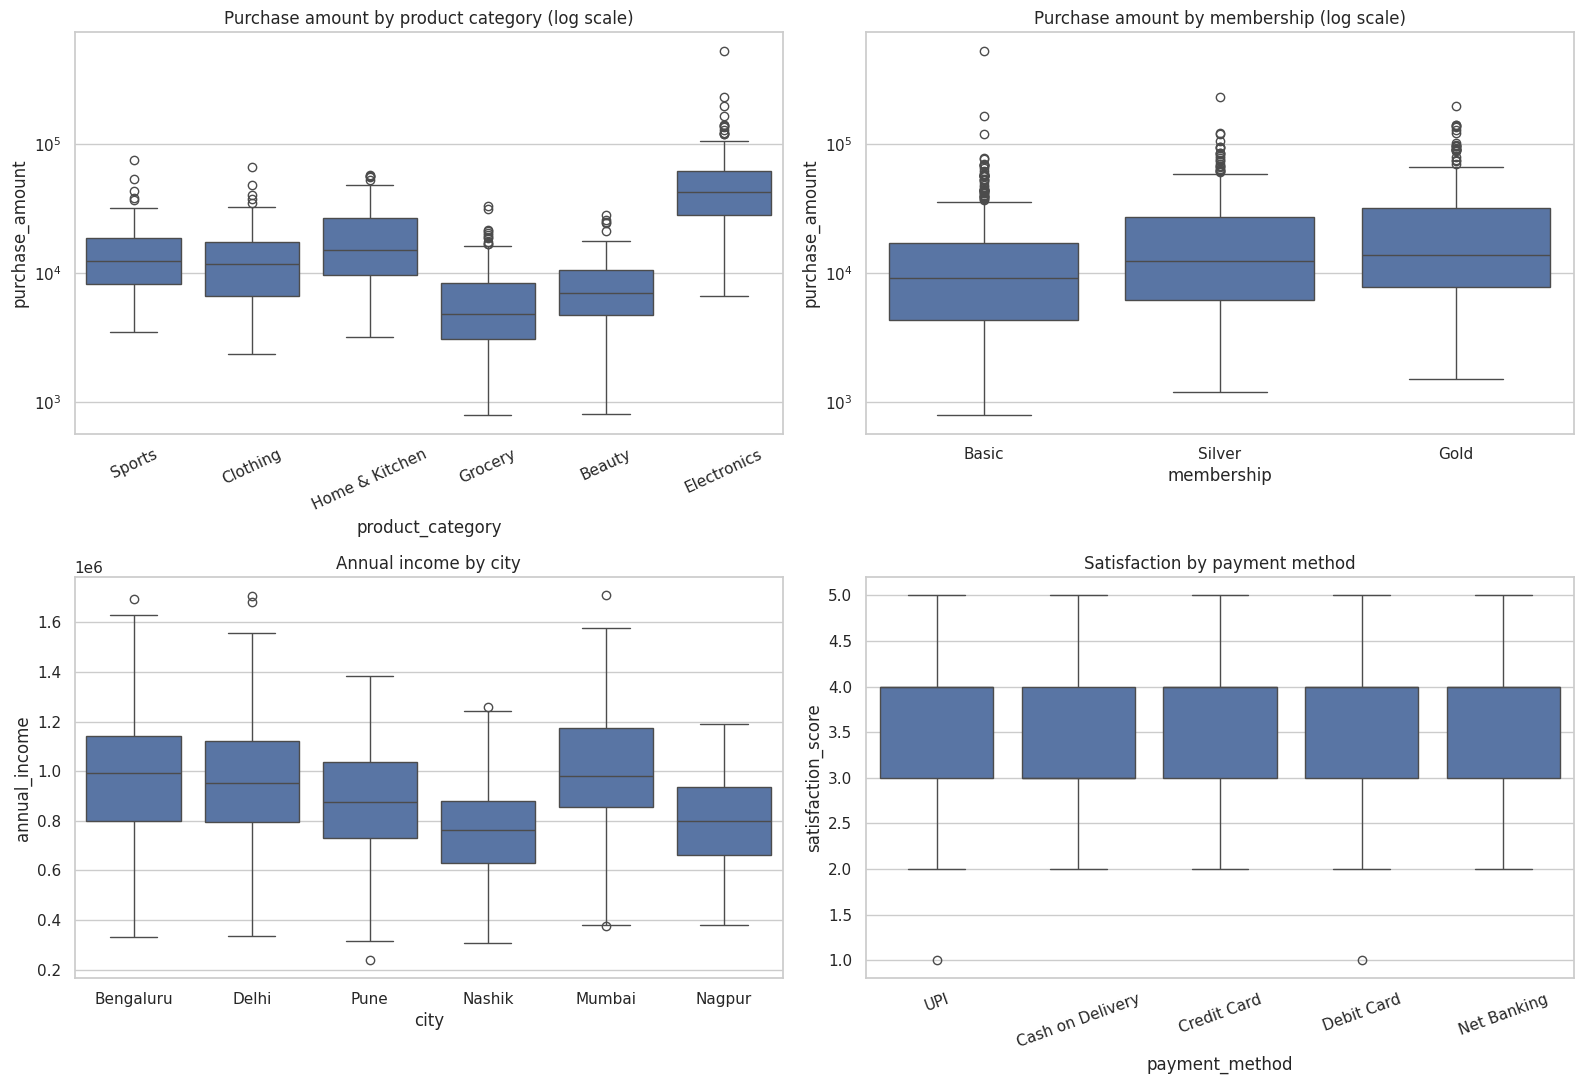


IQR outliers:
  purchase_amount             88 outliers (8.8%)
  annual_income                9 outliers (0.9%)
  days_since_last_purchase    44 outliers (4.4%)

Six largest purchases (all one-off high-value orders):
 customer_id product_category  quantity  purchase_amount
      C0866      Electronics         6        531421.68
      C0814      Electronics         5        230357.28
      C0027      Electronics         5        196281.43
      C0299      Electronics         2        166492.55
      C0119      Electronics         6        141884.93
      C0939      Electronics         5        140297.90


In [7]:
# STEP 5 - Box plots by category (distribution + outliers)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.boxplot(data=df, x="product_category", y="purchase_amount", ax=axes[0, 0])
axes[0, 0].set_yscale("log"); axes[0, 0].tick_params(axis="x", rotation=25)
axes[0, 0].set_title("Purchase amount by product category (log scale)")

sns.boxplot(data=df, x="membership", y="purchase_amount", order=["Basic", "Silver", "Gold"], ax=axes[0, 1])
axes[0, 1].set_yscale("log"); axes[0, 1].set_title("Purchase amount by membership (log scale)")

sns.boxplot(data=df, x="city", y="annual_income", ax=axes[1, 0])
axes[1, 0].set_title("Annual income by city")

sns.boxplot(data=df, x="payment_method", y="satisfaction_score", ax=axes[1, 1])
axes[1, 1].tick_params(axis="x", rotation=20); axes[1, 1].set_title("Satisfaction by payment method")
save("04_boxplots_by_category")

# Outliers by the IQR rule
print("\nIQR outliers:")
for c in ["purchase_amount", "annual_income", "days_since_last_purchase"]:
    s = df[c].dropna(); q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    n_out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    print(f"  {c:<26}{n_out:>4} outliers ({n_out/len(s):.1%})")
big = df.nlargest(6, "purchase_amount")[["customer_id", "product_category", "quantity", "purchase_amount"]]
print("\nSix largest purchases (all one-off high-value orders):\n", big.to_string(index=False))

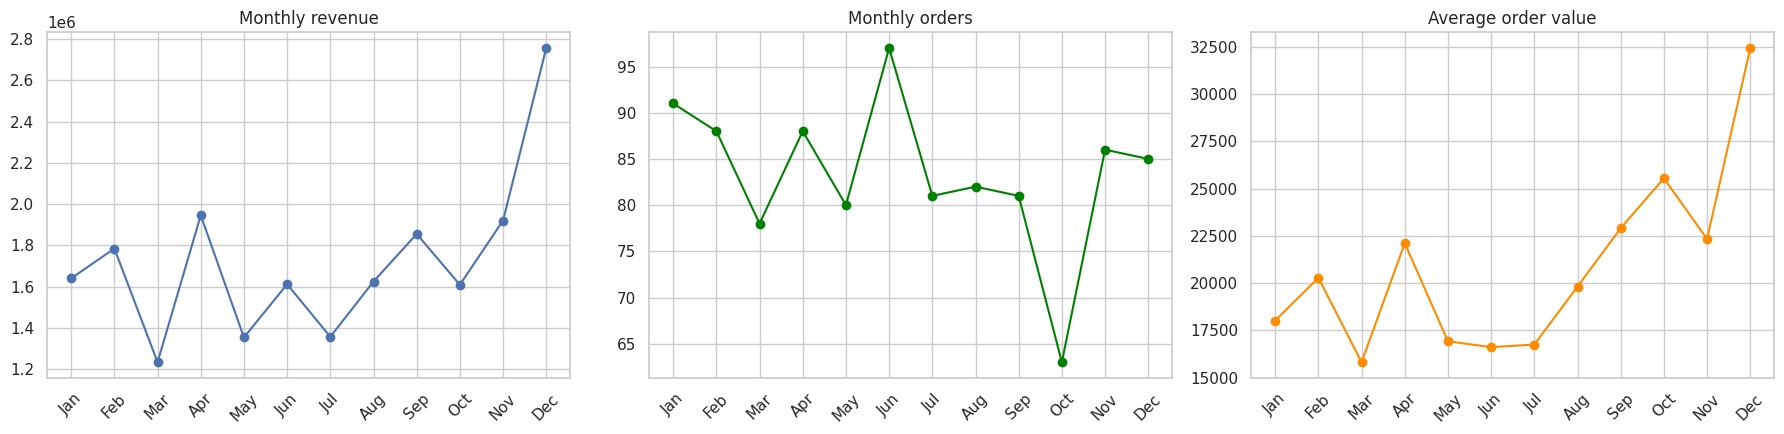

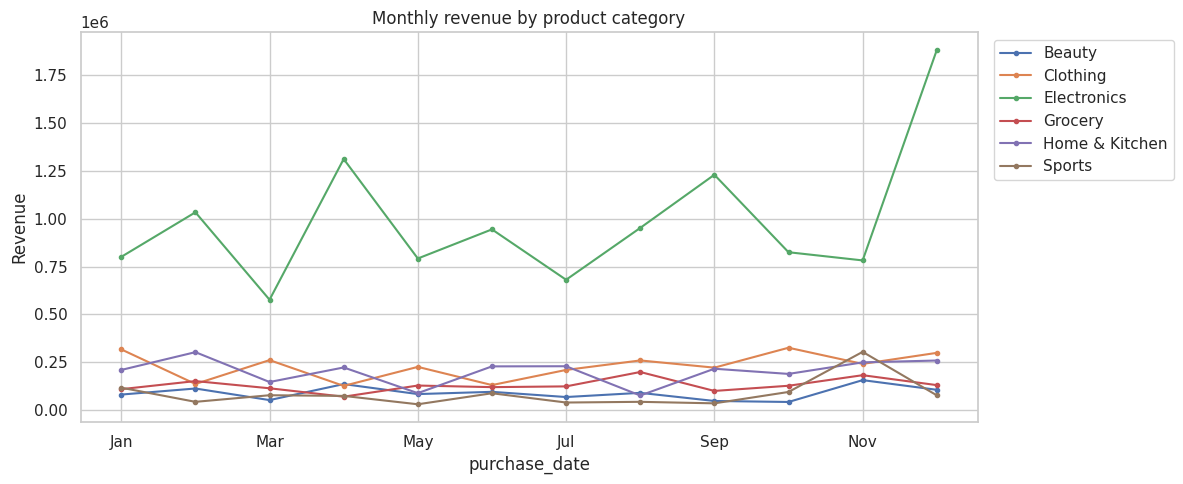

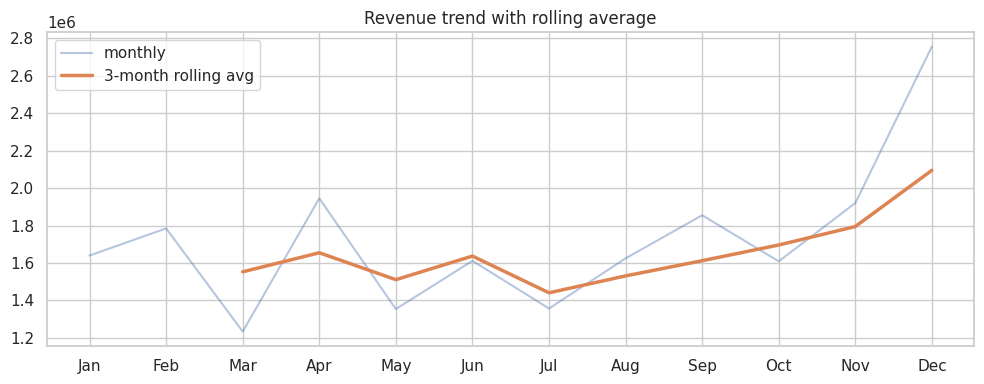


Revenue share by quarter (%):
 Q1    22.5
Q2    23.7
Q3    23.4
Q4    30.4
Name: purchase_amount, dtype: float64
Peak month: December


In [8]:
# STEP 6 - Trends over time (line charts)
ts = df.set_index("purchase_date").sort_index()
monthly = ts["purchase_amount"].resample("MS").agg(revenue="sum", orders="count", avg_order="mean")
monthly["month"] = monthly.index.strftime("%b")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(monthly["month"], monthly["revenue"], marker="o"); axes[0].set_title("Monthly revenue")
axes[1].plot(monthly["month"], monthly["orders"], marker="o", color="green"); axes[1].set_title("Monthly orders")
axes[2].plot(monthly["month"], monthly["avg_order"], marker="o", color="darkorange"); axes[2].set_title("Average order value")
for ax in axes: ax.tick_params(axis="x", rotation=45)
save("05_monthly_trends")

# Revenue by category over time
cat_month = (ts.groupby([pd.Grouper(freq="MS"), "product_category"])["purchase_amount"]
               .sum().unstack())
cat_month.index = cat_month.index.strftime("%b")
cat_month.plot(figsize=(12, 5), marker=".")
plt.title("Monthly revenue by product category"); plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
save("06_category_revenue_trend")

# Smoothed trend (3-month rolling average)
plt.figure(figsize=(10, 4))
plt.plot(monthly["month"], monthly["revenue"], alpha=.4, label="monthly")
plt.plot(monthly["month"], monthly["revenue"].rolling(3).mean(), lw=2.5, label="3-month rolling avg")
plt.title("Revenue trend with rolling average"); plt.legend()
save("07_revenue_rolling")

quarter = ts["purchase_amount"].resample("QS").sum()
q_share = (quarter / quarter.sum() * 100).round(1)
q_share.index = [f"Q{i}" for i in range(1, len(q_share) + 1)]
print("\nRevenue share by quarter (%):\n", q_share)
print("Peak month:", monthly["revenue"].idxmax().strftime("%B"))

# optional interactive version
if HAS_PLOTLY:
    fig_p = px.line(monthly.reset_index(), x="purchase_date", y="revenue", markers=True,
                    title="Monthly revenue (interactive)")
    fig_p.write_html("figures/monthly_revenue_interactive.html")


By product category:
                   orders     revenue  avg_order  median_order  avg_discount  avg_satisfaction  return_rate  revenue_share_%
product_category                                                                                                           
Electronics          226  11803875.0    52229.5       42646.8          11.7               3.6          4.0             57.0
Clothing             208   2765875.4    13297.5       11764.7          11.1               3.6         14.4             13.4
Home & Kitchen       121   2429420.9    20077.9       15212.9          10.6               3.6          5.8             11.7
Grocery              247   1569377.3     6353.8        4834.8          11.4               3.6          3.6              7.6
Beauty               134   1086179.7     8105.8        7064.8           9.9               3.6          3.0              5.2
Sports                64   1038782.0    16231.0       12382.4          11.1               3.6          3.1   

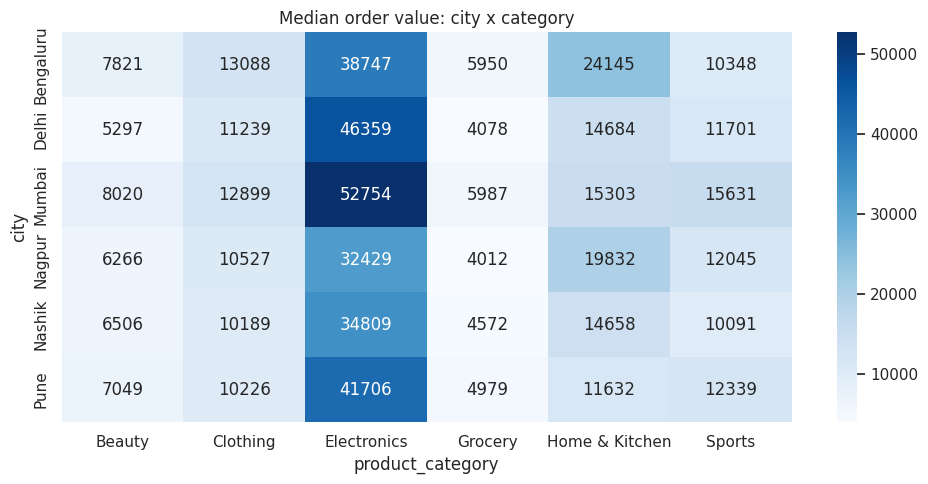

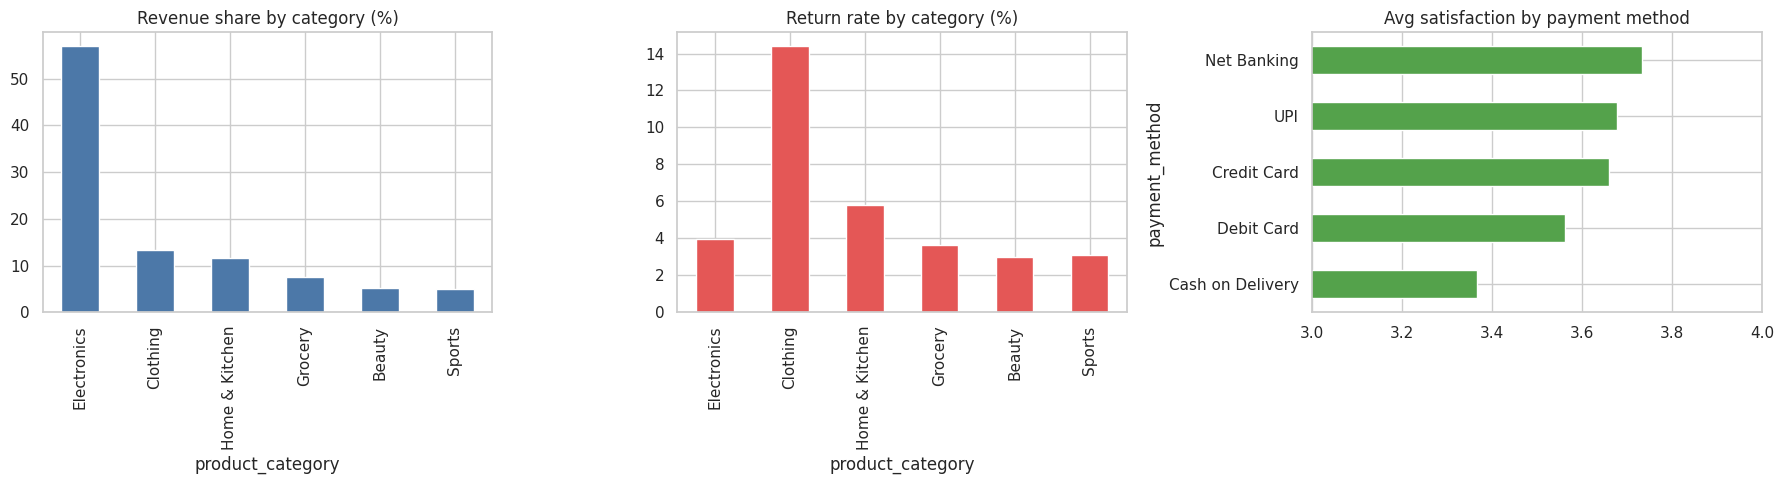

In [9]:
# STEP 7 - Group-by analysis on categorical variables
by_cat = (df.groupby("product_category")
            .agg(orders=("customer_id", "count"),
                 revenue=("purchase_amount", "sum"),
                 avg_order=("purchase_amount", "mean"),
                 median_order=("purchase_amount", "median"),
                 avg_discount=("discount_pct", "mean"),
                 avg_satisfaction=("satisfaction_score", "mean"),
                 return_rate=("returned", lambda s: (s == "Yes").mean() * 100))
            .sort_values("revenue", ascending=False))
by_cat["revenue_share_%"] = by_cat["revenue"] / by_cat["revenue"].sum() * 100
print("\nBy product category:\n", by_cat.round(1))

by_mem = (df.groupby("membership")
            .agg(customers=("customer_id", "count"), avg_age=("age", "mean"),
                 avg_income=("annual_income", "mean"), avg_order=("purchase_amount", "mean"),
                 median_order=("purchase_amount", "median"), avg_visits=("visits_per_month", "mean"),
                 avg_satisfaction=("satisfaction_score", "mean"))
            .loc[["Basic", "Silver", "Gold"]])
print("\nBy membership:\n", by_mem.round(1))

by_pay = (df.groupby("payment_method")
            .agg(orders=("customer_id", "count"), avg_satisfaction=("satisfaction_score", "mean"),
                 return_rate=("returned", lambda s: (s == "Yes").mean() * 100))
            .sort_values("avg_satisfaction"))
print("\nBy payment method:\n", by_pay.round(2))

by_city = (df.groupby("city")
             .agg(customers=("customer_id", "count"), avg_income=("annual_income", "mean"),
                  revenue=("purchase_amount", "sum"), avg_order=("purchase_amount", "mean"))
             .sort_values("revenue", ascending=False))
print("\nBy city:\n", by_city.round(0))

# Pivot: average order value, city x category
pivot = df.pivot_table(index="city", columns="product_category", values="purchase_amount", aggfunc="median")
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Median order value: city x category")
save("08_city_category_heatmap")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
by_cat["revenue_share_%"].plot(kind="bar", ax=axes[0], color="#4c78a8"); axes[0].set_title("Revenue share by category (%)")
by_cat["return_rate"].plot(kind="bar", ax=axes[1], color="#e45756"); axes[1].set_title("Return rate by category (%)")
by_pay["avg_satisfaction"].plot(kind="barh", ax=axes[2], color="#54a24b"); axes[2].set_title("Avg satisfaction by payment method")
axes[2].set_xlim(3, 4)
save("09_groupby_summary")


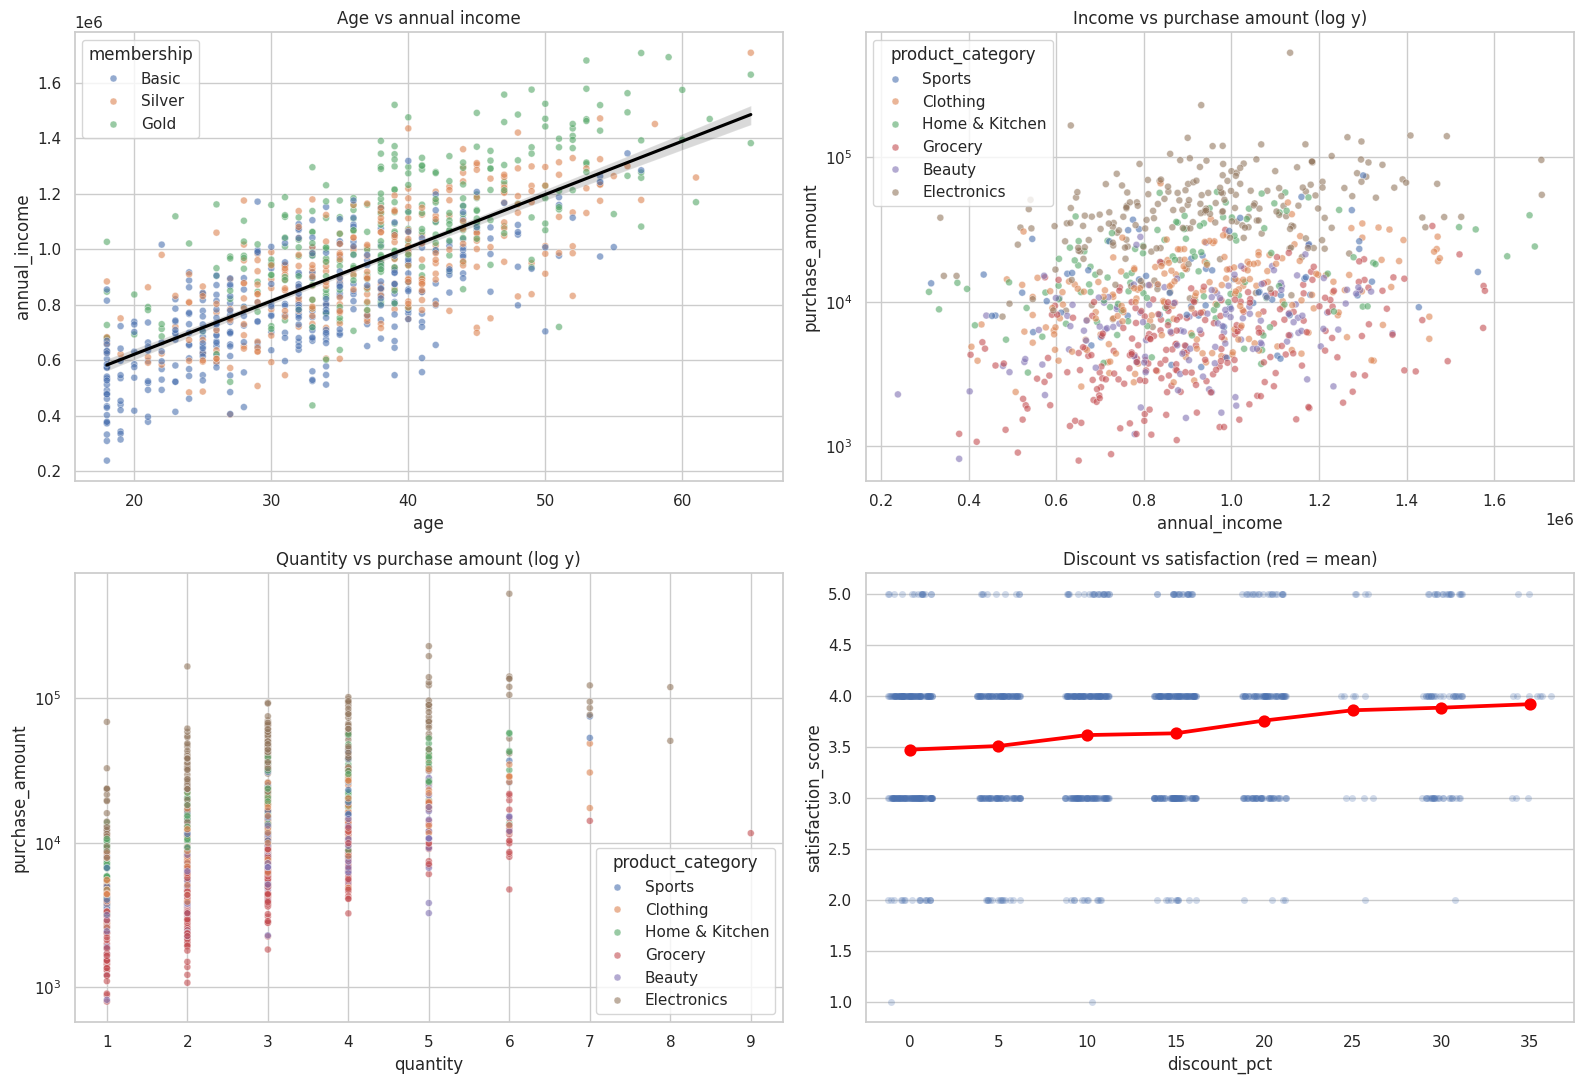

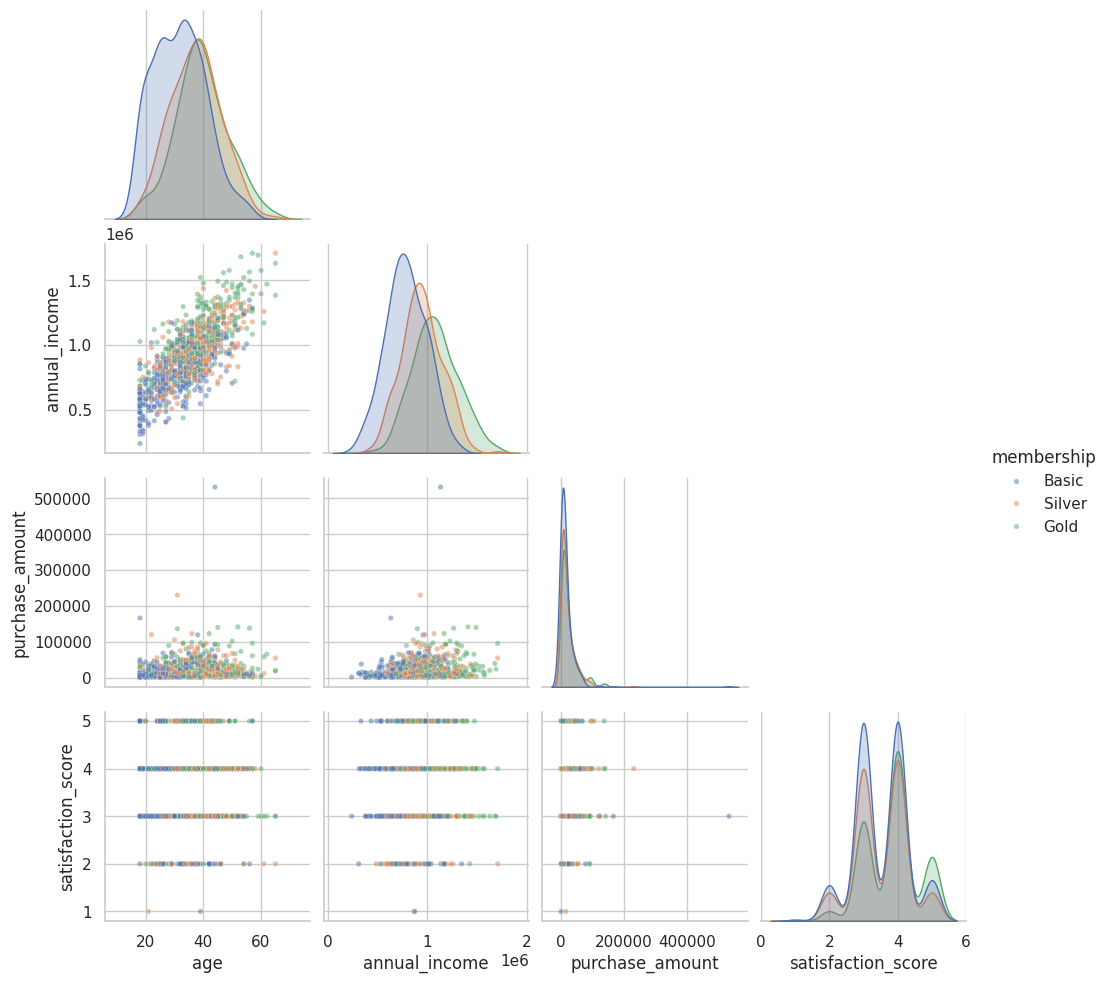

In [10]:
# STEP 8 - Scatter plots (relationships)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.scatterplot(data=df, x="age", y="annual_income", hue="membership", alpha=.6, s=25, ax=axes[0, 0])
sns.regplot(data=df, x="age", y="annual_income", scatter=False, color="black", ax=axes[0, 0])
axes[0, 0].set_title("Age vs annual income")

sns.scatterplot(data=df, x="annual_income", y="purchase_amount", hue="product_category", alpha=.6, s=25, ax=axes[0, 1])
axes[0, 1].set_yscale("log"); axes[0, 1].set_title("Income vs purchase amount (log y)")

sns.scatterplot(data=df, x="quantity", y="purchase_amount", hue="product_category", alpha=.6, s=25, ax=axes[1, 0])
axes[1, 0].set_yscale("log"); axes[1, 0].set_title("Quantity vs purchase amount (log y)")

sns.stripplot(data=df, x="discount_pct", y="satisfaction_score", alpha=.25, jitter=.25, ax=axes[1, 1])
sns.pointplot(data=df, x="discount_pct", y="satisfaction_score", color="red", errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title("Discount vs satisfaction (red = mean)")
save("10_scatter_relationships")

sns.pairplot(df[["age", "annual_income", "purchase_amount", "satisfaction_score", "membership"]].dropna(),
             hue="membership", corner=True, plot_kws={"alpha": .5, "s": 15}, hue_order=["Basic", "Silver", "Gold"])
plt.savefig("figures/11_pairplot.png", dpi=120)
plt.show()

if HAS_PLOTLY:
    fig_s = px.scatter(df, x="annual_income", y="purchase_amount", color="product_category",
                       size="quantity", hover_data=["customer_id", "city"], log_y=True,
                       title="Income vs purchase amount (interactive)")
    fig_s.write_html("figures/scatter_interactive.html")

In [11]:
# STEP 9 - Data-driven insights (computed, not hard-coded)
insights = []

# 1. Revenue concentration
rev = df.groupby("product_category")["purchase_amount"].sum().sort_values(ascending=False)
top_cat, top_share = rev.index[0], rev.iloc[0] / rev.sum() * 100
cat_orders = df["product_category"].value_counts(normalize=True)[top_cat] * 100
insights.append(f"**Revenue is concentrated in {top_cat}.** It is {cat_orders:.0f}% of orders but "
                f"{top_share:.0f}% of revenue; the top three categories bring in {rev.head(3).sum()/rev.sum()*100:.0f}%.")

# 2. Membership value
g = df.groupby("membership")["purchase_amount"].median()
insights.append(f"**Membership drives spend.** Median order value: Basic Rs {g['Basic']:,.0f}, "
                f"Silver Rs {g['Silver']:,.0f}, Gold Rs {g['Gold']:,.0f} "
                f"(Gold is {g['Gold']/g['Basic']:.1f}x Basic). Gold members also visit more "
                f"({by_mem.loc['Gold','avg_visits']:.1f} vs {by_mem.loc['Basic','avg_visits']:.1f} per month).")

# 3. Returns
rr = (df.assign(ret=df["returned"].eq("Yes")).groupby("product_category")["ret"].mean() * 100).sort_values(ascending=False)
overall = (df["returned"] == "Yes").mean() * 100
insights.append(f"**Returns are a Clothing problem.** {rr.index[0]} return rate is {rr.iloc[0]:.1f}% versus "
                f"{overall:.1f}% overall and {rr.iloc[-1]:.1f}% in {rr.index[-1]}.")

# 4. Cash on delivery
cod = df.loc[df.payment_method == "Cash on Delivery", "satisfaction_score"].mean()
oth = df.loc[df.payment_method != "Cash on Delivery", "satisfaction_score"].mean()
insights.append(f"**Cash on Delivery customers are less satisfied** ({cod:.2f} vs {oth:.2f} for other methods).")

# 5. Seasonality
q4 = q_share.iloc[-1]
# Robustness check: drop the top 1% of orders (extreme one-offs) and recompute Q4 share
trimmed = ts[ts["purchase_amount"] < ts["purchase_amount"].quantile(0.99)]["purchase_amount"].resample("MS").sum()
q4_trim = trimmed.iloc[-3:].sum() / trimmed.sum() * 100
top_order = df.loc[df["purchase_amount"].idxmax()]
insights.append(f"**Revenue peaks late in the year, but part of the peak is one big order.** "
                f"{monthly['revenue'].idxmax():%B} is the best month and Q4 delivers {q4:.0f}% of annual revenue "
                f"(an even split would be 25%). Excluding the top 1% of orders, Q4 is {q4_trim:.0f}%, so the "
                f"seasonal lift is real but modest; a single Rs {top_order['purchase_amount']:,.0f} order on "
                f"{top_order['purchase_date']:%d %b} inflates December. Order counts do not rise in Q4 - "
                f"the lift comes from higher average order value.")

# 6. Geography
ci = df.groupby("city")["annual_income"].mean().sort_values(ascending=False)
mix = pd.crosstab(df["city"], df["membership"], normalize="index")["Gold"] * 100
insights.append(f"**Customer value varies by city.** Average income is highest in {ci.index[0]} "
                f"(Rs {ci.iloc[0]:,.0f}) and lowest in {ci.index[-1]} (Rs {ci.iloc[-1]:,.0f}); "
                f"Gold share ranges from {mix.min():.0f}% ({mix.idxmin()}) to {mix.max():.0f}% ({mix.idxmax()}).")

# 7. Correlation caution
r_inc = df[["annual_income", "purchase_amount"]].corr(method="spearman").iloc[0, 1]
r_age = df[["age", "annual_income"]].corr().iloc[0, 1]
insights.append(f"**Income tracks age (r = {r_age:.2f}) but only weakly predicts order size** "
                f"(Spearman r = {r_inc:.2f}); what you buy and your membership tier matter far more than income.")

for i, t in enumerate(insights, 1):
    print(f"\n{i}. {t}")


1. **Revenue is concentrated in Electronics.** It is 23% of orders but 57% of revenue; the top three categories bring in 82%.

2. **Membership drives spend.** Median order value: Basic Rs 9,154, Silver Rs 12,430, Gold Rs 13,967 (Gold is 1.5x Basic). Gold members also visit more (4.7 vs 3.2 per month).

3. **Returns are a Clothing problem.** Clothing return rate is 14.4% versus 6.1% overall and 3.0% in Beauty.

4. **Cash on Delivery customers are less satisfied** (3.37 vs 3.65 for other methods).

5. **Revenue peaks late in the year, but part of the peak is one big order.** December is the best month and Q4 delivers 30% of annual revenue (an even split would be 25%). Excluding the top 1% of orders, Q4 is 27%, so the seasonal lift is real but modest; a single Rs 531,422 order on 20 Dec inflates December. Order counts do not rise in Q4 - the lift comes from higher average order value.

6. **Customer value varies by city.** Average income is highest in Mumbai (Rs 1,002,646) and lowest in 

In [12]:
# %% STEP 10 - Conclusions & business recommendations
conclusions = f"""
## Conclusions

The data describes a retail business whose revenue depends heavily on one category, whose
best customers are loyalty members, and whose main leaks are product returns and a weaker
cash-on-delivery experience. Spending is highly skewed: most orders are modest, while a
small number of large Electronics orders carry a disproportionate share of revenue, so
medians describe the typical customer better than means.

## Recommendations

1. **Protect and grow Electronics, but reduce the dependence on it.** Electronics gives
   {top_share:.0f}% of revenue. Prioritise stock availability and warranty/EMI offers there, and
   cross-sell Home & Kitchen and Beauty to Electronics buyers to broaden the base.
2. **Invest in the membership ladder.** Gold members spend more per order and visit more
   often. Offer targeted upgrades to high-income Silver customers, and consider welcome
   benefits for Basic members in cities where the Gold share is low.
3. **Fix Clothing returns.** A {rr.iloc[0]:.0f}% return rate is several times the other categories.
   Improve size guides and product photos, add fit/size reviews, and check the return reasons.
4. **Improve the cash-on-delivery experience.** Lower satisfaction suggests delivery or trust
   friction. Nudge COD customers to UPI with small incentives and audit COD delivery times.
5. **Plan for a modest Q4 lift.** Q4 brings {q4:.0f}% of revenue ({q4_trim:.0f}% without the top 1%
   of orders), driven by bigger baskets rather than more orders. Stock high-ticket items and
   bundles ahead of October, and test off-season promotions on the slower months.
6. **Use discounts selectively.** Discounts correlate only weakly with satisfaction, so deep
   discounts are not a reliable way to improve experience; reserve them for peak events and
   slow categories.

## Limitations

- The file contains a few missing values (income, visits, satisfaction); EDA ignores them.
- Correlation is not causation, and one year of data cannot show whether seasonality repeats.
- Group differences should be validated with significance tests before large investments.
"""
print(conclusions)

with open("eda_findings.md", "w", encoding="utf-8") as f:
    f.write("# EDA Findings - Retail Customers\n\n## Key insights\n\n")
    f.write("\n".join(f"{i}. {t}" for i, t in enumerate(insights, 1)))
    f.write("\n" + conclusions)
print("Saved eda_findings.md")


## Conclusions
 
The data describes a retail business whose revenue depends heavily on one category, whose
best customers are loyalty members, and whose main leaks are product returns and a weaker
cash-on-delivery experience. Spending is highly skewed: most orders are modest, while a
small number of large Electronics orders carry a disproportionate share of revenue, so
medians describe the typical customer better than means.
 
## Recommendations
 
1. **Protect and grow Electronics, but reduce the dependence on it.** Electronics gives
   57% of revenue. Prioritise stock availability and warranty/EMI offers there, and
   cross-sell Home & Kitchen and Beauty to Electronics buyers to broaden the base.
2. **Invest in the membership ladder.** Gold members spend more per order and visit more
   often. Offer targeted upgrades to high-income Silver customers, and consider welcome
   benefits for Basic members in cities where the Gold share is low.
3. **Fix Clothing returns.** A 14% return rate